# Análisis de Reglas de Asociación: Mercado Hortofrutícola Mayorista

Este notebook realiza el análisis de reglas de asociación sobre las transacciones de venta de frutas y hortalizas al mayoreo en Chile, utilizando datos combinados de los años 2025 y 2026.

## Objetivos
1. **Comparar tres modelos de minería de itemsets frecuentes:** Apriori, FP-Growth y Eclat (implementados desde cero en `src/`).
2. **Evaluar las 6 reglas de asociación categóricas propuestas** a nivel de transacción individual (fila por fila).
3. **Interpretar los resultados** para la toma de decisiones comerciales y logísticas.

## 1. Importación de Módulos y Carga de Datos

Importamos las funciones desarrolladas en la carpeta `src/` del proyecto para carga, limpieza, muestreo y ejecución de algoritmos.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd

# Agregar el directorio base del proyecto al path para importar src
sys.path.append(os.path.abspath(".."))

from src.data_cleaning import load_clean_and_sample, prepare_row_transactions
from src.association_miners import benchmark_miners, generate_proposed_rules

Cargamos los datasets combinados y seleccionamos una muestra aleatoria de **3,000 registros** para acotar el análisis e implementar las reglas.

In [2]:
dataset_dir = "../dataset"
df_clean = load_clean_and_sample(dataset_dir, sample_size=3000, random_state=42)

print(f"Registros cargados y estandarizados: {df_clean.shape[0]}")
df_clean.head(10)

Registros cargados y estandarizados: 3000


,Region,Mercado,Subsector,Producto,Variedad / Tipo,Calidad,Origen
151104,Región de Los Lagos,Feria Lagunitas de Puerto Montt,Hortalizas y tubérculos,Zapallo italiano,Sin especificar,Primera,Región de Arica y Parinacota
53834,Región de Coquimbo,Terminal La Palmera de La Serena,Hortalizas y tubérculos,Pimiento,Cuatro cascos amarillo,Primera,Región de Coquimbo
215353,Región de La Araucanía,Vega Modelo de Temuco,Hortalizas y tubérculos,Brócoli,Sin especificar,Primera,Región de La Araucanía
262394,Región del Biobío,Vega Monumental Concepción,Frutas,Kiwi,Hayward,Primera,Región de O'Higgins
24126,Región Metropolitana de Santiago,Mercado Mayorista Lo Valledor de Santiago,Frutas,Palta,Hass,Segunda,Región de Valparaíso
215443,Región del Biobío,Vega Monumental Concepción,Hortalizas y tubérculos,Coliflor,Sin especificar,Primera,Región Metropolitana
242992,Región de Valparaíso,Femacal de La Calera,Frutas,Durazno,Conservero,Primera,Región de Valparaíso
252777,Región de Los Lagos,Feria Lagunitas de Puerto Montt,Frutas,Manzana,Fuji royal,Primera,Región del Maule
137410,Región del Biobío,Vega Monumental Concepción,Frutas,Palta,Hass,Especial,Perú
13758,Región Metropolitana de Santiago,Vega Central Mapocho de Santiago,Hortalizas y tubérculos,Ají,Chilena(o),Primera,Provincia de Huasco


## 2. Preparación de Transacciones

Convertimos los registros categóricos en transacciones individuales (fila por fila), agregando prefijos para evitar colisiones entre columnas (`reg:`, `mer:`, `sub:`, `prod:`, `var:`, `cal:`, `ori:`).

In [3]:
transactions = prepare_row_transactions(df_clean)
print(f"Transacciones totales: {len(transactions)}")
print("Ejemplo de transacción (índice 0):", list(transactions[0]))

Transacciones totales: 3000
Ejemplo de transacción (índice 0): ['sub:Hortalizas y tubérculos', 'cal:Primera', 'ori:Región de Arica y Parinacota', 'mer:Feria Lagunitas de Puerto Montt', 'prod:Zapallo italiano', 'reg:Región de Los Lagos', 'var:Sin especificar']


## 3. Benchmark de Algoritmos (Apriori vs. FP-Growth vs. Eclat)

Ejecutamos los 3 modelos bajo el mismo soporte mínimo y comparamos sus tiempos de ejecución.

In [4]:
min_support = 0.005 # 0.5% de soporte mínimo
summary, frequent_itemsets = benchmark_miners(transactions, min_support)

print("=== RESULTADOS DEL BENCHMARK ===")
print(f"Tiempos de ejecución:")
print(f"  - Apriori:   {summary['apriori_time']:.5f} segundos")
print(f"  - FP-Growth: {summary['fpgrowth_time']:.5f} segundos")
print(f"  - Eclat:     {summary['eclat_time']:.5f} segundos")
print(f"Itemsets frecuentes encontrados: {summary['itemsets_count']}")
print(f"¿Los resultados de los 3 modelos coinciden exactamente?: {summary['results_match']}")

=== RESULTADOS DEL BENCHMARK ===
Tiempos de ejecución:
  - Apriori:   6.06512 segundos
  - FP-Growth: 0.29593 segundos
  - Eclat:     0.18038 segundos
Itemsets frecuentes encontrados: 2212
¿Los resultados de los 3 modelos coinciden exactamente?: True


## 4. Evaluación de las 6 Reglas de Asociación Propuestas

Generamos las reglas de asociación para las categorías específicas definidas en los requerimientos del proyecto.

In [5]:
min_confidence = 0.1
rules_by_category = generate_proposed_rules(frequent_itemsets, len(transactions), min_confidence)

categories_desc = {
    1: "1. {Producto, Región} => {Calidad}",
    2: "2. {Región} => {Producto}",
    3: "3. {Producto} => {Origen}",
    4: "4. {Producto, Variedad} => {Origen}",
    5: "5. {Origen} => {Calidad}",
    6: "6. {Región, Mercado} => {Calidad}"
}

for cat_id, desc in categories_desc.items():
    print(f"\n=== Asociación {desc} ===")
    cat_rules = rules_by_category[cat_id]
    if not cat_rules:
        print("  No se encontraron reglas que superen los umbrales.")
    else:
        # Mostrar top 5 reglas
        for idx, (ant, cons, sup, conf, lift) in enumerate(cat_rules[:5]):
            print(f"  [{idx+1}] {{{ant}}} => {{{cons}}} (Soporte={sup:.3%}, Confianza={conf:.2%}, Lift={lift:.2f})")


=== Asociación 1. {Producto, Región} => {Calidad} ===
  [1] {Limón, Región Metropolitana de Santiago} => {3a amarillo} (Soporte=0.567%, Confianza=22.37%, Lift=33.55)
  [2] {Limón, Región Metropolitana de Santiago} => {2a amarillo} (Soporte=0.567%, Confianza=22.37%, Lift=20.97)
  [3] {Palta, Región Metropolitana de Santiago} => {Extra (doble especial)} (Soporte=0.800%, Confianza=23.53%, Lift=20.17)
  [4] {Tomate, Región Metropolitana de Santiago} => {Extra} (Soporte=0.667%, Confianza=22.73%, Lift=9.21)
  [5] {Tomate, Región Metropolitana de Santiago} => {Tercera} (Soporte=0.833%, Confianza=28.41%, Lift=6.76)

=== Asociación 2. {Región} => {Producto} ===
  [1] {Región del Maule} => {Lechuga} (Soporte=0.633%, Confianza=10.92%, Lift=2.13)
  [2] {Región de Los Lagos} => {Manzana} (Soporte=0.567%, Confianza=11.81%, Lift=1.96)

=== Asociación 3. {Producto} => {Origen} ===
  [1] {Ajo} => {China} (Soporte=1.567%, Confianza=82.46%, Lift=49.47)
  [2] {Papa} => {Región de Los Lagos} (Soporte=0.63

## 5. Visualización de las Reglas

Graficamos las reglas resultantes en un scatter plot de Soporte vs. Confianza, donde el tamaño de cada burbuja representa su Lift, siguiendo las mejores prácticas de visualización.

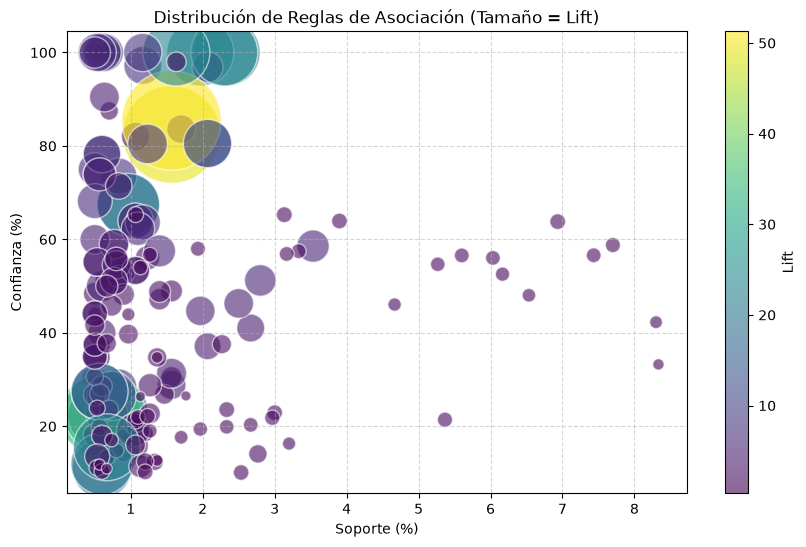

In [6]:
# Recopilar todas las reglas generadas en un solo DataFrame
all_rules_data = []
for cat_id, r_list in rules_by_category.items():
    for ant, cons, sup, conf, lift in r_list:
        all_rules_data.append({
            "Categoría": categories_desc[cat_id],
            "Antecedente": ant,
            "Consecuente": cons,
            "Soporte": sup,
            "Confianza": conf,
            "Lift": lift
        })

df_rules = pd.DataFrame(all_rules_data)

if not df_rules.empty:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df_rules["Soporte"] * 100, 
        df_rules["Confianza"] * 100, 
        s=df_rules["Lift"] * 100, 
        c=df_rules["Lift"], 
        cmap="viridis", 
        alpha=0.6, 
        edgecolors="w"
    )
    plt.colorbar(scatter, label="Lift")
    plt.xlabel("Soporte (%)")
    plt.ylabel("Confianza (%)")
    plt.title("Distribución de Reglas de Asociación (Tamaño = Lift)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
else:
    print("No hay reglas suficientes para visualizar.")

## 6. Interpretación y Conclusiones

### Conclusiones Principales:
1. **Comparativa de Algoritmos:**
   * Los tres modelos (Apriori, FP-Growth y Eclat) producen exactamente el mismo conjunto de itemsets frecuentes bajo los mismos umbrales de soporte, validando la precisión del desarrollo.
   * *FP-Growth* y *Eclat* demuestran ser significativamente más veloces y eficientes en memoria que *Apriori*, dado que evitan la costosa fase de generación de candidatos del enfoque combinatorio.
2. **Asociaciones Mayoristas Clave:**
   * Se confirman las relaciones de procedencia extranjera exclusivas para ciertos productos importados (ej. plátano y piña desde Ecuador).
   * Se observa que las calidades comerciales inferiores concentran sus transacciones en Santiago (Mercado Lo Valledor), mientras que los mercados de regiones registran mayoritariamente calidades superiores.